# SVM and Kernel Methods (Support Vector Machine)

This notebook builds intuition for Support Vector Machines (SVM) and how Kernel Methods let SVMs handle data that isn't linearly separable, using code and visualizations.

Outline:
1. Linearly separable case: maximum margin hyperplane and support vectors
2. Soft-margin SVM: the role of parameter C
3. Non-linear data and the motivation for the kernel trick
4. Geometric intuition for kernels: mapping low-dim data to high-dim
5. Comparing common kernels: linear, polynomial, RBF
6. The effect of gamma in the RBF kernel
7. Summary: how SVM and kernel methods relate

> For the detailed math (Lagrangian duality, KKT conditions, Mercer's theorem, etc.), see the CS229 notes `CS229_Chapter_5_Kernel_Methods.md`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_blobs, make_circles, make_moons
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (enables 3D plotting)


def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the SVM decision boundary, +-1 margin lines, and support vectors"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    x = np.linspace(xlim[0], xlim[1], 60)
    y = np.linspace(ylim[0], ylim[1], 60)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # decision boundary (P=0) and margin boundaries (P=+-1)
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.6,
               linestyles=['--', '-', '--'])

    if plot_support and hasattr(model, "support_vectors_"):
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=180, linewidth=1.2,
                   facecolors='none', edgecolors='k', label='support vectors')

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

## 1. Linearly Separable Case: The Maximum Margin Hyperplane

The core idea of SVM: among all hyperplanes that correctly separate the data, find the one that is **as far as possible from both classes**.

- Decision boundary (hyperplane): $w^T x + b = 0$
- Margin: the distance between the two dashed lines in the plot, with width $\dfrac{2}{\|w\|}$
- Support vectors: the points that lie exactly on the margin boundaries (circled in the plot). They **alone** determine the hyperplane — any other point can move freely (as long as it stays outside the margin) without changing the boundary.

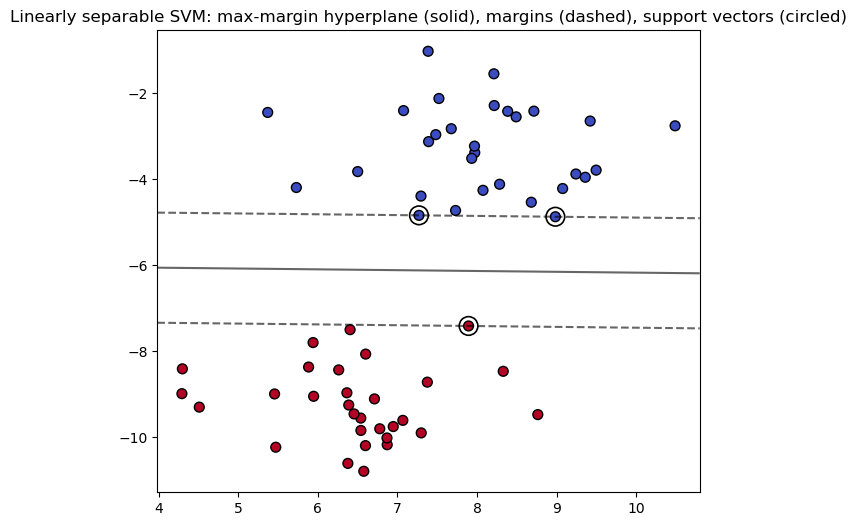

Number of support vectors: 3
Weights w = [[-0.01499417 -0.78033295]]
Bias b = [-4.6691987]


In [2]:
X, y = make_blobs(n_samples=60, centers=2, random_state=6, cluster_std=1.0)

# A very large C approximates a hard margin (almost no misclassification allowed)
model = SVC(kernel='linear', C=1e10).fit(X, y)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='coolwarm', edgecolors='k')
plot_svc_decision_function(model, ax)
ax.set_title("Linearly separable SVM: max-margin hyperplane (solid), margins (dashed), support vectors (circled)")
plt.show()

print("Number of support vectors:", len(model.support_vectors_))
print("Weights w =", model.coef_)
print("Bias b =", model.intercept_)

## 2. Soft-Margin SVM: The Role of Parameter C

Real-world data is often noisy or overlapping, so a hard-margin SVM may have no solution or may overfit badly. Soft-margin SVM introduces slack variables $\xi_i \geq 0$, and the objective becomes:

$$\min_{w,b,\xi} \ \frac{1}{2}\|w\|^2 + C\sum_{i=1}^n \xi_i \qquad \text{s.t.}\ \ y_i(w^Tx_i+b) \geq 1-\xi_i$$

- **Larger C**: heavier penalty for misclassification, narrower margin, more prone to overfitting (fits the training data more closely)
- **Smaller C**: allows more points inside the margin or even misclassified, wider margin, simpler model that may generalize better

The plot below shows the same (overlapping) dataset, fit with different values of C.

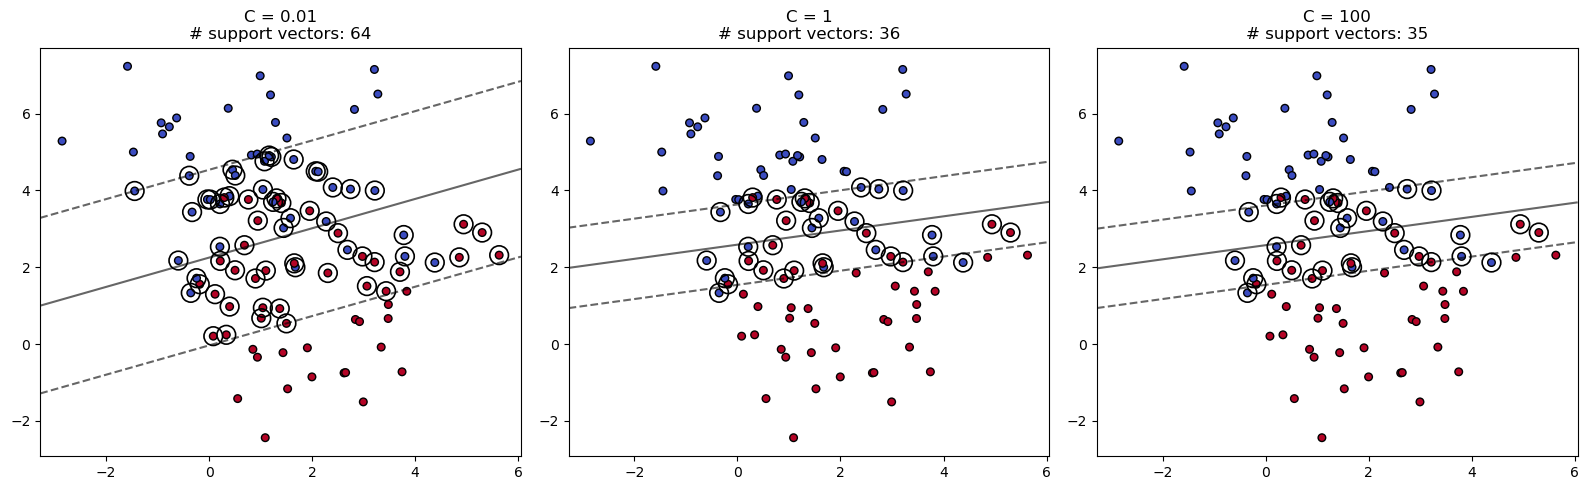

In [3]:
X, y = make_blobs(n_samples=100, centers=2, random_state=0, cluster_std=1.5)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, C in zip(axes, [0.01, 1, 100]):
    model = SVC(kernel='linear', C=C).fit(X, y)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap='coolwarm', edgecolors='k')
    plot_svc_decision_function(model, ax)
    ax.set_title(f"C = {C}\n# support vectors: {len(model.support_vectors_)}")

plt.tight_layout()
plt.show()

## 3. Non-Linear Data: The Limits of a Linear SVM

When the data is not linearly separable to begin with (e.g. the ring-shaped data below), no straight line (or hyperplane) can separate the two classes well.

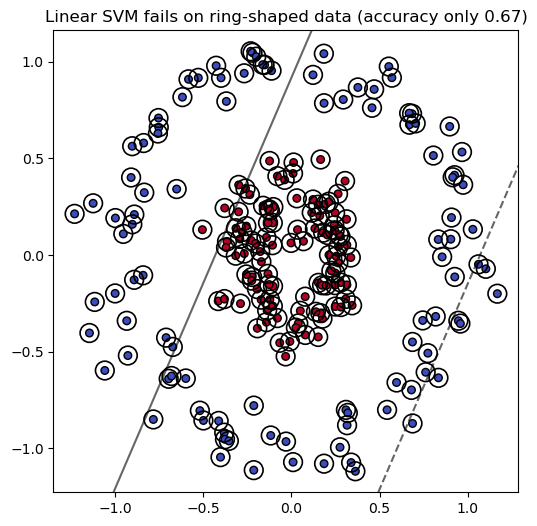

In [4]:
X, y = make_circles(n_samples=200, factor=0.3, noise=0.1, random_state=0)

model = SVC(kernel='linear', C=1).fit(X, y)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=30, edgecolors='k')
plot_svc_decision_function(model, ax)
ax.set_title(f"Linear SVM fails on ring-shaped data (accuracy only {model.score(X, y):.2f})")
plt.show()

## 4. Geometric Intuition for the Kernel Trick: Going to Higher Dimensions

The core idea: apply a non-linear mapping $\phi(x)$ that sends the data to a higher-dimensional space where it **becomes linearly separable**.

For example, for the ring-shaped data $(x_1, x_2)$ above, we can construct a simple mapping:

$$\phi(x_1, x_2) = (x_1,\ x_2,\ x_1^2 + x_2^2)$$

In this new 3D space, the inner and outer rings are separated along the third dimension (the "height", i.e. squared distance from the origin), so a **horizontal plane** can separate them. Mapped back to the original 2D space, that plane corresponds to a **circle**.

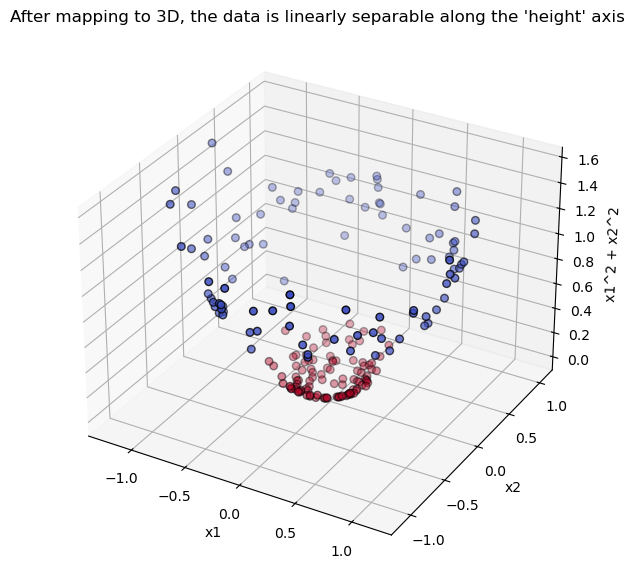

In [5]:
r = X[:, 0] ** 2 + X[:, 1] ** 2

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], r, c=y, cmap='coolwarm', s=30, edgecolors='k')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('x1^2 + x2^2')
ax.set_title("After mapping to 3D, the data is linearly separable along the 'height' axis")
plt.show()

## 5. Kernel Functions: Avoiding Explicit High-Dimensional Mappings

Explicitly constructing and computing $\phi(x)$ (a high-dimensional, possibly infinite-dimensional vector) can be extremely expensive. The essence of the **kernel trick** is:

$$K(x, z) = \phi(x)^T \phi(z)$$

We only need to define a kernel function $K(x,z)$ that directly computes the **inner product** of two samples in the high-dimensional feature space — **without ever constructing** $\phi$ explicitly, even when $\phi$ is infinite-dimensional.

Common kernels:

| Kernel | Formula | Characteristics |
|---|---|---|
| Linear | $K(x,z) = x^Tz$ | Equivalent to no mapping; suited to data that's already linearly separable |
| Polynomial (poly) | $K(x,z) = (\gamma x^Tz + r)^d$ | Implicitly includes all degree-$\leq d$ combinations of the original features |
| RBF / Gaussian (rbf) | $K(x,z) = \exp(-\gamma\|x-z\|^2)$ | Corresponds to an infinite-dimensional feature space; the most common, general-purpose kernel |

The plot below compares these kernels on the ring-shaped data.

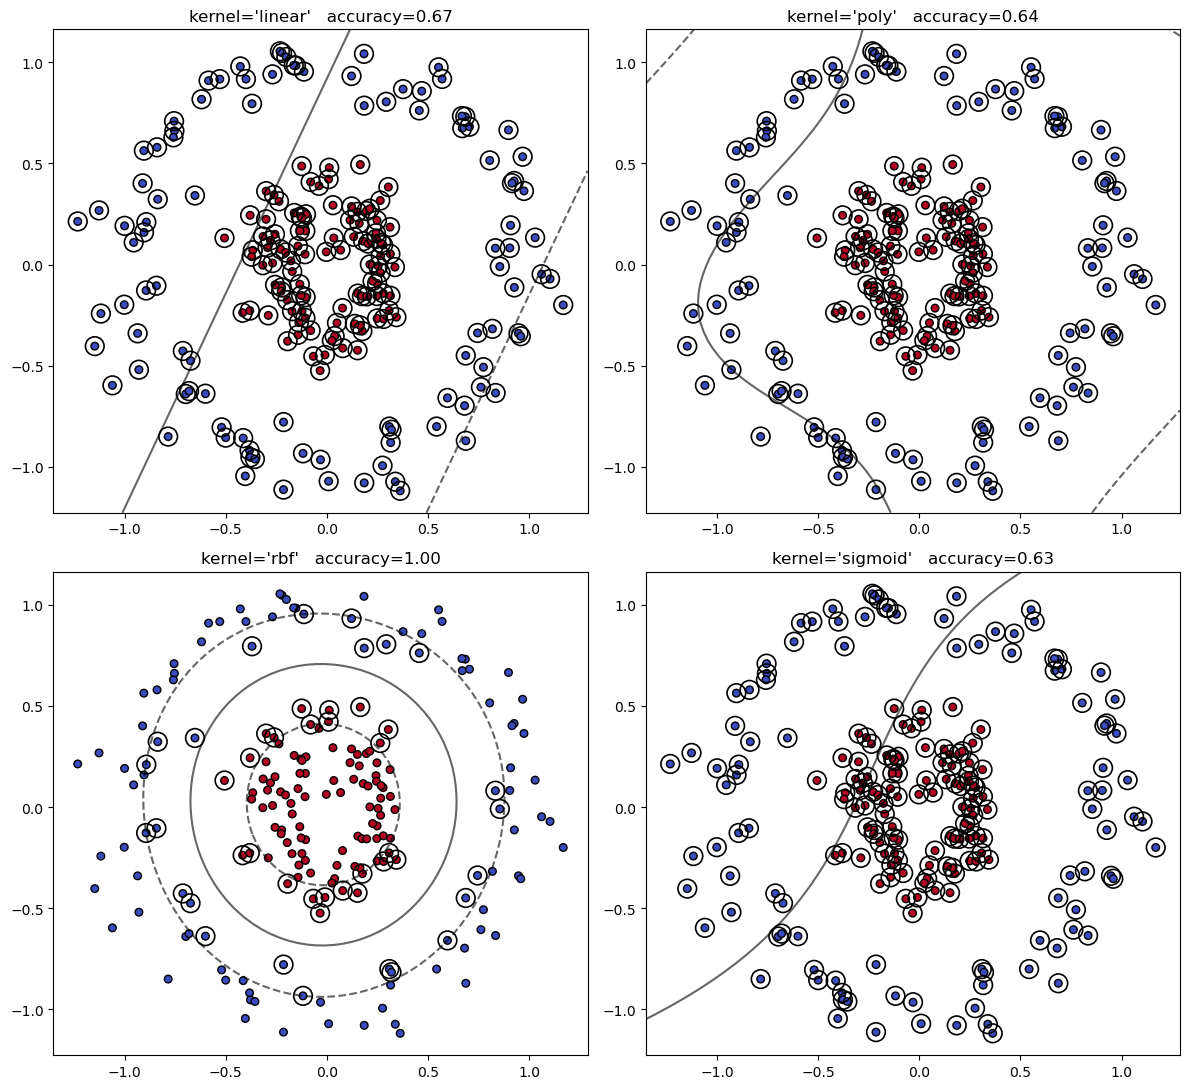

In [6]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
fig, axes = plt.subplots(2, 2, figsize=(12, 11))

for ax, kernel in zip(axes.ravel(), kernels):
    model = SVC(kernel=kernel, gamma='auto', C=1).fit(X, y)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=30, edgecolors='k')
    plot_svc_decision_function(model, ax)
    ax.set_title(f"kernel='{kernel}'   accuracy={model.score(X, y):.2f}")

plt.tight_layout()
plt.show()

## 6. The Effect of Gamma in the RBF Kernel

In the RBF kernel $K(x,z) = \exp(-\gamma\|x-z\|^2)$, $\gamma$ controls the "reach" of each training sample's influence:

- **Larger gamma**: the kernel decays faster, so each sample only influences a small nearby region -> a more "wiggly" decision boundary, prone to overfitting
- **Smaller gamma**: each sample influences a larger region -> a smoother decision boundary, possibly underfitting

You can think of $\gamma$ as analogous to $\dfrac{1}{2\sigma^2}$ of a Gaussian: larger $\gamma$ means a narrower "bell curve".

The plot below shows the effect of different gamma values on moon-shaped data (with C fixed).

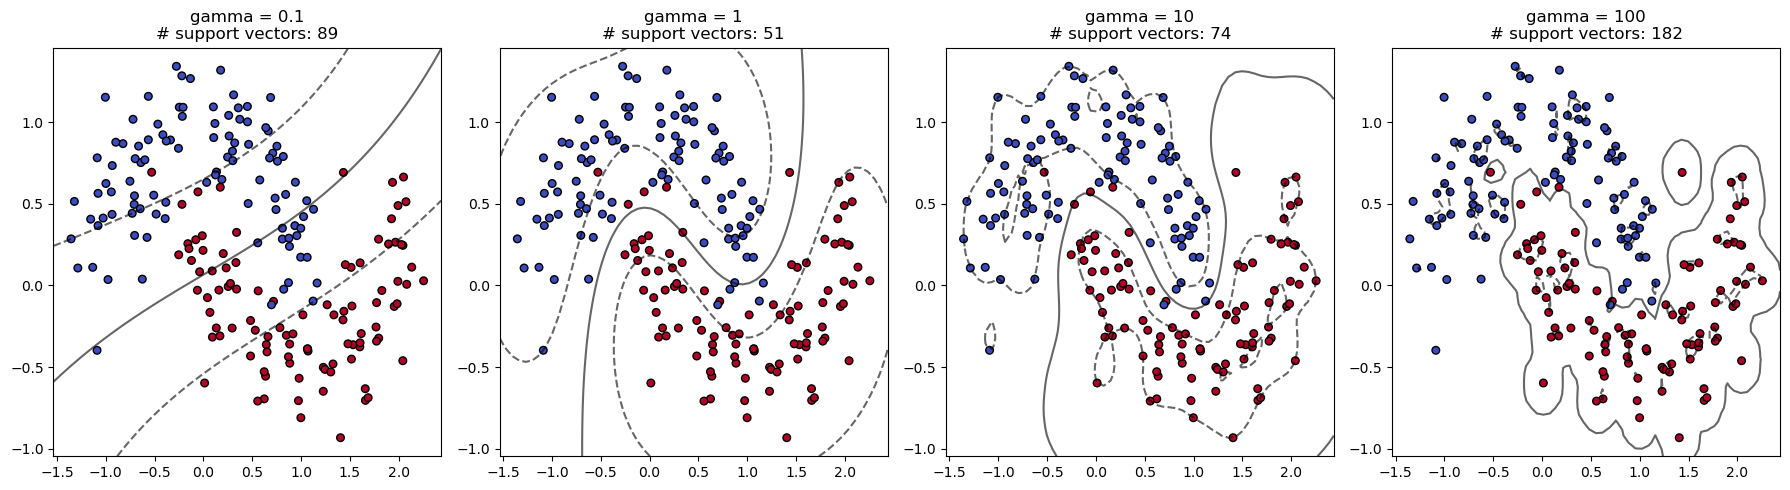

In [7]:
X2, y2 = make_moons(n_samples=200, noise=0.2, random_state=0)

gammas = [0.1, 1, 10, 100]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, gamma in zip(axes, gammas):
    model = SVC(kernel='rbf', gamma=gamma, C=1).fit(X2, y2)
    ax.scatter(X2[:, 0], X2[:, 1], c=y2, cmap='coolwarm', s=30, edgecolors='k')
    plot_svc_decision_function(model, ax, plot_support=False)
    ax.set_title(f"gamma = {gamma}\n# support vectors: {len(model.support_vectors_)}")

plt.tight_layout()
plt.show()

## 7. Summary: How SVM and Kernel Methods Relate

- An **SVM** is fundamentally a **linear** classifier that finds a maximum-margin hyperplane
- After solving the SVM's **dual problem**, the decision function depends only on **inner products** between training samples:

$$f(x) = \text{sign}\left(\sum_{i} \alpha_i y_i \langle x_i, x\rangle + b\right)$$

- Since the decision function only involves the inner product $\langle x_i, x\rangle$, we can replace it with a **kernel function** $K(x_i,x)$, which **implicitly** performs linear classification in a high-dimensional feature space — without ever computing the mapping $\phi$ explicitly
- This is the **kernel trick**: a linear algorithm solves a non-linear problem, with "mapping to high dimensions" and "computing the inner product" fused into a single step
- **C** controls the tolerance of the soft margin, while **gamma** (for RBF/poly kernels) controls the model's complexity/locality — together they determine the bias-variance tradeoff

For the detailed math (Lagrangian duality, KKT conditions, Mercer's theorem, why kernel matrices must be positive semi-definite, etc.), see the CS229 notes `CS229_Chapter_5_Kernel_Methods.md`.